# SETUP

In [1]:
%pip install transformer_lens
%pip install torchtyping
# Install my janky personal plotting utils
%pip install git+https://github.com/neelnanda-io/neel-plotly.git
# Install another version of node that makes PySvelte work way faster
%pip install circuitsvis
# Needed for PySvelte to work, v3 came out and broke things...
%pip install typeguard==2.13.3

  Using cached typeguard-4.4.2-py3-none-any.whl.metadata (3.8 kB)
Using cached typeguard-4.4.2-py3-none-any.whl (35 kB)
  Attempting uninstall: typeguard
    Found existing installation: typeguard 2.13.3
    Uninstalling typeguard-2.13.3:
      Successfully uninstalled typeguard-2.13.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchtyping 0.1.5 requires typeguard<3,>=2.11.1, but you have typeguard 4.4.2 which is incompatible.
Note: you may need to restart the kernel to use updated packages.
  Using cached typeguard-2.13.3-py3-none-any.whl.metadata (3.6 kB)
Using cached typeguard-2.13.3-py3-none-any.whl (17 kB)
  Attempting uninstall: typeguard
    Found existing installation: typeguard 4.4.2
    Uninstalling typeguard-4.4.2:
      Successfully uninstalled typeguard-4.4.2
ERROR: pip's dependency resolver does not currently take into account all the package

# Main Code

In [2]:
# utils.py
from dataclasses import dataclass
from typing import Optional, Tuple, List
from tqdm import tqdm, trange
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import einops
from fancy_einsum import einsum
from transformer_lens import ActivationCache


def get_logit_diff(logits, answer_token_indices, clean_baseline=None,
                  corrupted_baseline=None):
    if len(logits.shape) == 3:
        # Get final logits only
        logits = logits[:, -1, :]
    correct_logits = logits.gather(1, answer_token_indices[:, 0].unsqueeze(1))
    incorrect_logits = logits.gather(1, answer_token_indices[:, 1].unsqueeze(1))
    score = (correct_logits - incorrect_logits).mean()

    assert (clean_baseline is None) == (corrupted_baseline is None), \
      "Either both or neither of clean_baseline and corrupted_baseline should be provided."
    if clean_baseline is not None:
        score = (score - corrupted_baseline) / (clean_baseline - corrupted_baseline)
    return score

## hook utils
def filter_mlp_hooks(name):
    return "mlp" in name

def get_cache_fwd_and_bwd(model, tokens, metric):
    model.reset_hooks()
    cache = {}

    def forward_cache_hook(act, hook):
        cache[hook.name] = act.detach()

    model.add_hook(filter_mlp_hooks, forward_cache_hook, "fwd")
    grad_cache = {}

    def backward_cache_hook(act, hook):
        grad_cache[hook.name] = act.detach()

    model.add_hook(filter_mlp_hooks, backward_cache_hook, "bwd")

    value = metric(model(tokens))
    value.backward()
    model.reset_hooks()
    return (
        value.item(),
        ActivationCache(cache, model),
        ActivationCache(grad_cache, model),
    )

def get_cache_fwd(model, tokens, metric):
    model.reset_hooks()
    cache = {}

    def forward_cache_hook(act, hook):
        cache[hook.name] = act.detach()

    model.add_hook(filter_mlp_hooks, forward_cache_hook, "fwd")
    grad_cache = {}

    value = metric(model(tokens))
    model.reset_hooks()
    return (
        value.item(),
        ActivationCache(cache, model),
        ActivationCache(grad_cache, model),
    )


## stacking utils (not very necessary -- but keep for simplicity)
def stack_mlp_from_cache(model, cache, activation_name):
    stacked_mlp_vectors = torch.stack(
        [cache[activation_name, l] for l in range(model.cfg.n_layers)], dim=0
    )
    return stacked_mlp_vectors

def stack_w_out(model):
    W_out_stacked = torch.stack(
        [model.blocks[l].mlp.W_out for l in range(model.cfg.n_layers)], dim=0
    )
    return W_out_stacked

def stack_w_in(model):
    W_in_stacked = torch.stack(
        [model.blocks[l].mlp.W_in.T for l in range(model.cfg.n_layers)], dim=0
    )
    return W_in_stacked


## circuit
def get_attribution_scores(clean_cache, corrupted_cache, grad_cache, sum_over_pos=False,
                           do_abs=True):
    clean_act = stack_mlp_from_cache(model, clean_cache, "post")
    corrupted_act = stack_mlp_from_cache(model, corrupted_cache, "post")
    grad_vector = stack_mlp_from_cache(model, grad_cache, "post")

    attribution_scores = einops.reduce(
        grad_vector * (clean_act - corrupted_act),
        "layer batch pos d_mlp -> layer pos d_mlp",
        "sum"
    )
    if do_abs:
      attribution_scores = attribution_scores.abs()
    if sum_over_pos:
        attribution_scores = einops.reduce(
            attribution_scores,
            "layer pos d_mlp -> layer d_mlp",
            "sum"
        )
    return attribution_scores


def compute_circuit_mask(attribution_scores, topk=50, exclude_layers=[0, 1]):
    topk_relevant_layers = torch.arange(len(attribution_scores))[~torch.isin(torch.arange(len(attribution_scores)), torch.tensor(exclude_layers))]
    topk_values, _ = torch.topk(attribution_scores[topk_relevant_layers].flatten(), k=topk)
    threshold = topk_values[-1].item()
    mask = attribution_scores >= threshold
    mask[exclude_layers] = 0
    return mask


def visualize_mask(model, mask, prompt):
    mask_sum = mask.sum(-1)
    str_tokens = model.tokenizer.tokenize(prompt)
    plt.matshow(mask_sum)
    plt.xticks(np.arange(len(str_tokens) + 1), ['<bos>'] + str_tokens, rotation=45)

    for (i, j), val in np.ndenumerate(mask_sum):
        if val != 0:  # Only add text for non-zero values
            plt.text(j, i, f'{val:.0f}', ha='center', va='center', color='w')


def find_circuit(model, clean_tokens, corrupted_tokens, answer_token_indices):
    '''
    Find the circuit for the given model and tokens
    '''
    # Get the logits and cache for both clean and corrupted tokens
    clean_logits, clean_cache = model.run_with_cache(clean_tokens)
    corrupted_logits, corrupted_cache = model.run_with_cache(corrupted_tokens)
    clean_logit_diff = get_logit_diff(clean_logits, answer_token_indices).item()
    corrupted_logit_diff = get_logit_diff(corrupted_logits, answer_token_indices).item()

    metric = lambda logits: get_logit_diff(
        logits, answer_token_indices,
        clean_baseline=clean_logit_diff,
        corrupted_baseline=corrupted_logit_diff
    )

    # Get the cache for the forward and backward passes
    _, clean_cache, clean_grad_cache = get_cache_fwd_and_bwd(model, clean_tokens, metric)
    _, corrupted_cache, _ = get_cache_fwd(model, corrupted_tokens, metric)

    # Get the circuit mask
    attribution_scores = get_attribution_scores(
        clean_cache, corrupted_cache, clean_grad_cache, sum_over_pos=False, do_abs=True
        )
    return attribution_scores

## analysis
def similarity_matrix(mat_pruned, normalize=True, remove_mean=False, eps=1e-10):
  mat_pruned = mat_pruned.clone()
  if remove_mean:
    mat_pruned -= mat_pruned.mean(dim=0, keepdim=True)
  if normalize:
    mat_pruned /= mat_pruned.norm(dim=-1, keepdim=True) + eps
  return mat_pruned @ mat_pruned.T


# slicing utils
def get_slices(l,pos,l2,pos2, lpos2counts):

    '''
    return the offset of the neurons of (l,pos) in the influence tensor of (l2,pos2)
    '''
    assert l2 > l and pos2 >= pos

    start = sum(lpos2counts[k] for k in lpos2counts if (k[0] < l2 and k[1] <= pos2) and (k[0] < l or k[1] < pos))
    end = start + lpos2counts[l, pos]

    return start, end


/opt/homebrew/Caskroom/miniconda/base/envs/nlp_circuits/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
# influence.py
from functools import partial
import torch
from torch.func import vmap
import einops


def compute_neuron_influence(model, tokens, influencing_neuron, eps=0.01, do_abs=True):
    """
    Calculate counterfactual effect of a neuron on all other neurons.

    Args:
        model: The transformer model (from transformer_lens)
        tokens: Input tokens to the model
        influencing_neuron: Tuple of (layer, neuron_idx, pos) for the influencing neuron
        eps: Small perturbation to apply
        do_abs: Whether to take the absolute value of the influence scores

    Returns:
        influence_scores: Tensor of shape [n_layers, seq_len, d_mlp] containing activation differences
    """
    layer, pos, neuron_idx = influencing_neuron
    batch_size = tokens.shape[0]
    n_layers = model.cfg.n_layers
    d_mlp = model.cfg.d_mlp
    seq_len = tokens.shape[1]

    # Run baseline forward pass
    model.reset_hooks()
    _, baseline_cache = model.run_with_cache(tokens)

    # Function to perturb the specified neuron activation
    def perturb_neuron_hook(act, hook):
        perturbed_act = act.clone()
        perturbed_act[:, pos, neuron_idx] += eps
        return perturbed_act

    # Run perturbed forward pass
    model.reset_hooks()
    model.add_hook(f"blocks.{layer}.mlp.hook_post", perturb_neuron_hook, "fwd")
    _, perturbed_cache = model.run_with_cache(tokens)
    model.reset_hooks()

    # Create influence mask
    influence_scores = torch.zeros((n_layers, seq_len, d_mlp), device=tokens.device)

    # Compute effect on all neurons at once
    for l in range(n_layers):
        layer_name = f"blocks.{l}.mlp.hook_post"
        baseline_acts = baseline_cache[layer_name]  # Shape: [batch, seq_len, d_mlp]
        perturbed_acts = perturbed_cache[layer_name]  # Same shape
        diffs = (perturbed_acts - baseline_acts) / eps
        if do_abs:
          diffs = diffs.abs()
        influence_scores[l] = diffs.mean(dim=0)  # Mean over batch
    return influence_scores


def jacobian(outputs, inputs, chunk_size=None):
    """Efficiently compute Jacobian using vmap and vjp with optional chunking.

    Args:
        outputs: tensor of shape (output_dim,)
        inputs: tensor of shape (input_dim,)
        chunk_size: int, size of chunks to process at once (None means no chunking)
    Returns:
        Jacobian of shape (output_dim, input_dim)
    """
    original_output_shape = outputs.shape
    outputs = outputs.flatten()
    output_dim = outputs.shape[0]
    basis = torch.eye(output_dim, device=inputs.device)

    # Define vjp function for a single basis vector
    def get_vjp(basis_vector):
        with torch.enable_grad():
            grad, = torch.autograd.grad(outputs, inputs, basis_vector, retain_graph=True)
        return grad

    # If no chunking is needed, just use vmap directly
    if chunk_size is None or chunk_size >= output_dim:
        result = vmap(get_vjp)(basis)
    else:
      # Process in chunks to avoid memory issues
      chunks = []
      for i in trange(0, output_dim, chunk_size):
          end_idx = min(i + chunk_size, output_dim)
          chunk_basis = basis[i:end_idx]
          chunk_result = vmap(get_vjp)(chunk_basis).cpu().detach()
          chunks.append(chunk_result)

      # Concatenate results from all chunks
      result = torch.cat(chunks, dim=0)
    return result.unflatten(dim=0, sizes=original_output_shape)


def approx_influence_on_layer(model, mask, tokens, target_layer, target_pos,
                              lpos2counts=None, source_layers=None, do_abs=False, chunk_size=None
                              ):
    """
    Approximate the influence on a specific layer-position pair from previous tokens and layers.
    Gradients are used to approximate the influence. Non-linearitys are detached.

    Args:
        model: The transformer model (from transformer_lens)
        mask: the mask represents a boolean chooser of neurons [n_layers, seq_len, d_mlp]
        tokens: Input tokens to the model
        target_layer: target layer index
        target_pos: target position index
        source_layers: List of source layer indices (default: all layers before target)
        do_abs: Whether to take absolute values of the jacobian
        chunk_size: chunk size for jacobian calculation
        lpos2counts: Optional dictionary mapping (layer, pos) to activate neuron counts for slicing

    Returns:
        influence_tensor: tensor is of shape [target_selected_neurons, selected_neurons],
                          where selected_neurons is the number of active neurons in mask,
                          after truncating it to target_pos. While target_selected_neurons
                          are the active neurons in mask[target_layer, target_pos]
    """
    
    NONLINEAR_TYPES = (
        nn.LayerNorm,
        nn.BatchNorm1d, nn.BatchNorm2d, nn.BatchNorm3d,
        nn.ReLU, nn.GELU, nn.Sigmoid, nn.Tanh,
        nn.Softmax, nn.Dropout,
    )

    def detach_nonlinearity_outputs(model):
        """
        Register forward-hooks on every module in model whose type is in NONLINEAR_TYPES,
        so that its output is immediately .detach()'d.
        Returns a list of hook-handles which you must remove() later.
        """
        handles = []
        for module in model.modules():
            if isinstance(module, NONLINEAR_TYPES):
                # hook fires after the module's forward, detaching its output
                handle = module.register_forward_hook(
                    lambda mod, inputs, output: output.detach()
                )
                handles.append(handle)
        return handles



    try:
        model.reset_hooks()
        activations = {}
        mask = mask[:, :target_pos + 1]
        if tokens.shape[0] != 1:
            raise NotImplementedError

        if source_layers is None:
            source_layers = list(range(target_layer))

        def save_activation_hook(act, hook, layer):
            # hack to make it work with jacobian(..), as usually even slicing the input vector
            # invalidates the computational graph (ie, trying to derive wrt act[layer_mask])
            layer_mask = mask[layer]
            relevant_act = act[:, layer_mask].requires_grad_(True)
            full_act = act.clone().detach().requires_grad_(False)
            full_act[:, layer_mask] = relevant_act
            activations[hook.name] = relevant_act
            return full_act

        # Add hooks for all needed layers
        hook_names = []
        for layer_idx in source_layers + [target_layer]:
            hook_name = f"blocks.{layer_idx}.mlp.hook_post"
            hook_names.append(hook_name)
            model.add_hook(hook_name, partial(save_activation_hook, layer=layer_idx), "fwd")
        handles = detach_nonlinearity_outputs(model)

        # Forward pass
        model(tokens[:, :target_pos+1])

        # Get target activations
        target_hook_name = f"blocks.{target_layer}.mlp.hook_post"
        target_activations = activations[target_hook_name]

        if lpos2counts is not None:
            start = sum(lpos2counts[k] for k in lpos2counts if k[0] == target_layer and k[1] < target_pos)
            end = start + lpos2counts[target_layer, target_pos]
            target_pos_activations = target_activations[:, start:end]
        else:
            target_pos_activations = target_activations[:, target_pos]
            
        assert target_activations.shape[0] == 1
        target_pos_activations = target_pos_activations.squeeze(0) # because batch size == 1
        device = tokens.device
        d_mlp = model.cfg.d_mlp
        seq_len = target_pos

        layer_influences = []

        # Compute full jacobian for each source layer
        for i, source_layer in enumerate(source_layers):
            source_hook_name = f"blocks.{source_layer}.mlp.hook_post"
            source_activations = activations[source_hook_name]

            # Compute full jacobian first [output_dim, *input_dims] = [target_selected_neurons (output), batch_size (input), selected_neurons (input)]
            full_jac = jacobian(target_pos_activations, source_activations, chunk_size=chunk_size)
            if do_abs:
                full_jac = full_jac.abs()
            assert full_jac.shape[1] == 1
            layer_influences.append(full_jac.mean(dim=1))

        model.reset_hooks()

        influences =  torch.cat(layer_influences, dim=1)

    finally:
        for h in handles:
            h.remove()

    return influences

Loaded pretrained model gpt2-small into HookedTransformer


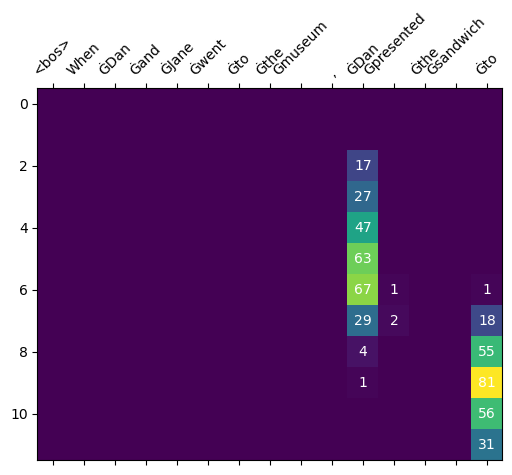

In [6]:
# main.py
# from .utils import *
from transformer_lens import HookedTransformer
import torch
import random

def generate_ioi_data(num_samples):
    """Generate random IOI-style samples (prompts + (IO, S) answers)."""

    # Some example names, places, objects, and verbs
    names = [
        "John", "Mary", "Tom", "Amy", "James", "Alice", "Mark", "Lisa",
        "Dan", "Max", "Sam", "Eva", "Jane", "Luke",
        "Bob", "Kate", "Ben"
    ]
    places = [
        "the store", "the park", "the shops", "the beach",
        "the museum", "the school", "the cafe", "the mall"
    ]
    objects = [
        "bag", "ball", "apple", "book", "drink", "gift",
        "sandwich", "toy", "phone", "note"
    ]
    verbs = [
        "gave", "handed", "passed", "offered", "brought",
        "delivered", "presented"
    ]

    clean_prompts, corrupted_prompts = [], []
    answers = []

    for _ in range(num_samples):
        # Pick 2 distinct names
        name1, name2 = random.sample(names, 2)
        # Pick a place, object, and verb
        place = random.choice(places)
        obj = random.choice(objects)
        verb = random.choice(verbs)

        # Randomly choose who is subject (giver) and who is indirect object (receiver)
        if random.random() < 0.5:
            subject = name1
            indirect_object = name2
        else:
            subject = name2
            indirect_object = name1

        # Construct the prompt
        prompt1 = f"When {name1} and {name2} went to {place}, {subject} {verb} the {obj} to"
        prompt2 = f"When {name1} and {name2} went to {place}, {indirect_object} {verb} the {obj} to"

        # The answer is (IO, S) in a tuple
        answers_tuple = (indirect_object, subject)

        clean_prompts.append(prompt1)
        corrupted_prompts.append(prompt2)
        answers.append(answers_tuple)

    return clean_prompts, corrupted_prompts, answers


if __name__ == "__main__":
    num_samples = 3000
    num_circuit_samples = 8 # Number of samples to use for circuit finding

    ## Load the model
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = HookedTransformer.from_pretrained("gpt2-small", device=device)
    model.set_use_attn_result(True)
    model.set_use_attn_in(True)
    model.set_use_hook_mlp_in(True)

    ## Generate IOI data
    clean_prompts, corrupted_prompts, answers = generate_ioi_data(num_samples)
    clean_tokens = model.to_tokens(clean_prompts)
    corrupted_tokens = model.to_tokens(corrupted_prompts)

    # print("Clean string 0", model.to_string(clean_tokens[0]))
    # print("Corrupted string 0", model.to_string(corrupted_tokens[0]))

    answer_token_indices = torch.tensor(
        [
            [model.to_single_token(answers[i][j]) for j in range(2)]
            for i in range(len(answers))
        ],
        device=model.cfg.device,
    )
    # print("Answer token indices", answer_token_indices)

    ## Find the circuit
    attribution_scores = find_circuit(model,
                                      clean_tokens[:num_circuit_samples],
                                      corrupted_tokens[:num_circuit_samples],
                                      answer_token_indices[:num_circuit_samples])
    mask = compute_circuit_mask(attribution_scores, topk=500, exclude_layers=[0, 1])
    visualize_mask(model, mask.cpu(), clean_prompts[0])
    plt.savefig("ioi_circuit.png")
    plt.show()

    ## Fetching the relevant neurons by mask
    # batch_size = 8
    # activation_vectors = []
    # with torch.no_grad():
    #     for i in trange(0, num_samples, batch_size):
    #         _, clean_cache = model.run_with_cache(clean_tokens[i:i + batch_size])
    #         clean_act = stack_mlp_from_cache(model, clean_cache, "post")
    #         clean_act = einops.rearrange(clean_act, "layer batch pos d_mlp -> layer pos d_mlp batch")
    #         relevant_neurons = clean_act[mask, :].cpu().detach()
    #         activation_vectors.append(relevant_neurons)
    # activation_vectors = torch.cat(activation_vectors, dim=-1)

# Circuit Evaluation

In [7]:
def get_ablated_outputs(ablation_hook, model, prompts):
    def filter_mlp_out_hooks(name):
        return "post" in name and "mlp" in name
    model.reset_hooks()
    model.add_hook(filter_mlp_out_hooks, ablation_hook, "fwd")
    tokens = model.to_tokens(prompts)
    with torch.no_grad():
        output = model(tokens)
    model.reset_hooks()
    return output

## Zero Ablation

In [13]:
mask = compute_circuit_mask(attribution_scores, topk=500, exclude_layers=[0, 1])

def zero_ablation(act, hook):
    layer = int(hook.name.split(".")[1])
    layer_mask = mask[layer].int()
    ablated_act = torch.einsum(
        "bpm,pm->bpm",
        act,
        layer_mask
    )
    return ablated_act

prompts, _, answers = generate_ioi_data(8)
output = get_ablated_outputs(zero_ablation, model, prompts)
# print the predictions
for l in range(8):
    print("prompt", prompts[l])
    print("Answer", answers[l])
    print("Predictions", model.to_string(output[l, -1].argmax(dim=-1)))
    print()

prompt When Sam and Alice went to the shops, Sam presented the phone to
Answer ('Alice', 'Sam')
Predictions <|endoftext|>

prompt When Jane and Luke went to the store, Jane brought the phone to
Answer ('Luke', 'Jane')
Predictions <|endoftext|>

prompt When Amy and Kate went to the cafe, Amy presented the note to
Answer ('Kate', 'Amy')
Predictions <|endoftext|>

prompt When James and Bob went to the cafe, Bob offered the toy to
Answer ('James', 'Bob')
Predictions <|endoftext|>

prompt When Alice and Luke went to the cafe, Alice brought the sandwich to
Answer ('Luke', 'Alice')
Predictions <|endoftext|>

prompt When Bob and Kate went to the cafe, Kate gave the book to
Answer ('Bob', 'Kate')
Predictions <|endoftext|>

prompt When Ben and John went to the museum, John delivered the toy to
Answer ('Ben', 'John')
Predictions <|endoftext|>

prompt When Mark and Tom went to the store, Mark delivered the sandwich to
Answer ('Tom', 'Mark')
Predictions <|endoftext|>



## Mean Ablation 

We do mean ablation in the same way suggested in the IOI paper sampling from p_abc 

In [8]:
def generate_abc_data(num_samples):
    """Generate random ABC-style samples (IOI prompts but with 3 different names)."""

    # Some example names, places, objects, and verbs
    names = [
        "John", "Mary", "Tom", "Amy", "James", "Alice", "Mark", "Lisa",
        "Dan", "Max", "Sam", "Eva", "Jane", "Luke",
        "Bob", "Kate", "Ben"
    ]
    places = [
        "the store", "the park", "the shops", "the beach",
        "the museum", "the school", "the cafe", "the mall"
    ]
    objects = [
        "bag", "ball", "apple", "book", "drink", "gift",
        "sandwich", "toy", "phone", "note"
    ]
    verbs = [
        "gave", "handed", "passed", "offered", "brought",
        "delivered", "presented"
    ]

    prompts = []

    for _ in range(num_samples):
        # Pick 2 distinct names
        name1, name2, name3 = random.sample(names, 3)
        # Pick a place, object, and verb
        place = random.choice(places)
        obj = random.choice(objects)
        verb = random.choice(verbs)

        # Construct the prompt
        prompt1 = f"When {name1} and {name2} went to {place}, {name3} {verb} the {obj} to"
        
        prompts.append(prompt1)

    return prompts

In [9]:
prompts = generate_abc_data(256)
prompts_tokens = model.to_tokens(prompts)

with torch.no_grad():
    model.reset_hooks()
    _, activation_cache = model.run_with_cache(prompts_tokens)

mean_activations = torch.stack(
        [
            einops.reduce(
                activation_cache[f'blocks.{l}.mlp.hook_post'],
                "batch pos d_mlp -> pos d_mlp",
                "mean"
            )
            for l in range(model.cfg.n_layers)
        ], dim=0
    ).to(model.cfg.device)

In [ ]:
mask = compute_circuit_mask(attribution_scores, topk=150000, exclude_layers=[0])

def mean_ablation(act, hook):
    layer = int(hook.name.split(".")[1])

    layer_mask = einops.rearrange(mask[layer].int(), 'n e -> 1 n e')

    ablated_act = act * layer_mask + mean_activations[layer] * (1 - layer_mask)
    return ablated_act

prompts, _, answers = generate_ioi_data(8)
output = get_ablated_outputs(mean_ablation, model, prompts)

answers = [answers[i][0].strip() for i in range(len(answers))]
top_5 = output[:, -1].topk(5).indices

acc = len([i for i in range(len(answers)) if answers[i] in model.to_string(top_5[i])]) / len(answers)

for l in range(8):
    print("prompt", prompts[l])
    
    print("Predictions", model.to_string(output[l, -1].argmax(dim=-1)))
    top_5 = output[l, -1].topk(5).indices
    print("Top 5 predictions", model.to_string(top_5))
    print()
    

Top 5 predictions tensor([[  606,   607, 14235,   262,   683],
        [  606,   607,   262,   683,   465],
        [  606,   607,   262, 14862,   683],
        [  606, 11336,   607,   262,   683],
        [  606,   607,   262, 15378,   465],
        [  606,   607, 16693,   262,   511],
        [  607,   606, 14862,   262, 12091],
        [  607,   606, 16693,   262,   683]])
Answers ['Dan', 'Ben', 'Alice', 'Sam', 'Lisa', 'Ben', 'Alice', 'John']
Top 5 predictions [' them her Amy the him', ' them her the him his', ' them her the Alice him', ' them Luke her the him', ' them her the Lisa his', ' them her Kate the their', ' her them Alice the Jane', ' her them Kate the him']
Accuracy 0.375
prompt When Amy and Dan went to the store, Amy gave the book to
Predictions  them
Top 5 predictions  them her Amy the him

prompt When Mark and Ben went to the shops, Mark passed the sandwich to
Predictions  them
Top 5 predictions  them her the him his

prompt When Dan and Alice went to the school, Dan o

## Eval

100%|██████████| 150/150 [02:23<00:00,  1.05it/s]


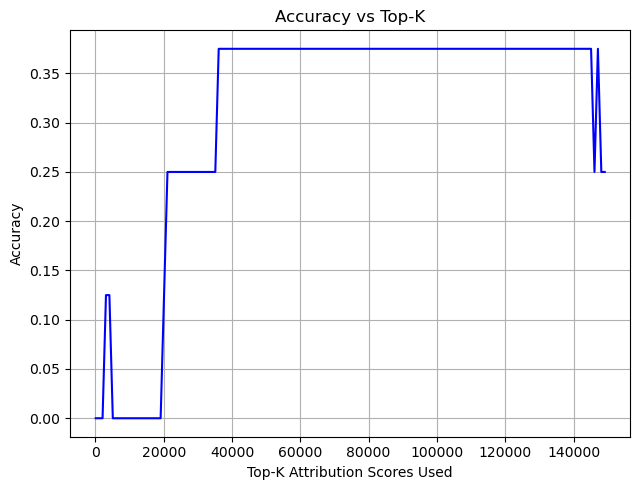

In [ ]:
from torch import log_softmax, softmax


accuracies = []
logit_diffs = []
kl_divs = []

prompts, _, answers = generate_ioi_data(8) 
answers = [answers[i][0].strip() for i in range(len(answers))]

ks = range(100, 150001, 1000)
for k in tqdm(ks):
    mask = compute_circuit_mask(attribution_scores, topk=k, exclude_layers=[])

    def mean_ablation(act, hook):
        layer = int(hook.name.split(".")[1])

        layer_mask = einops.rearrange(mask[layer].int(), 'n e -> 1 n e')

        ablated_act = act * layer_mask + mean_activations[layer].unsqueeze(0) * (1 - layer_mask)
        return ablated_act

    output = get_ablated_outputs(mean_ablation, model, prompts)

    top_5 = output[:, -1].topk(5).indices

    acc = len([i for i in range(len(answers)) if answers[i] in model.to_string(top_5[i])]) / len(answers)

    accuracies.append(acc)


# Plotting
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.plot(ks, accuracies, label="Accuracy", color="blue")
plt.xlabel("Top-K Attribution Scores Used")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Top-K")
plt.grid(True)

# plt.subplot(1, 3, 2)
# plt.plot(ks, logit_diffs, label="Logit Diff", color="red")
# plt.xlabel("Top-K Attribution Scores Used")
# plt.ylabel("Mean Logit Diff")
# plt.title("Logit Difference vs Top-K")
# plt.grid(True)

# plt.subplot(1, 3, 3)
# plt.plot(ks, kl_divs, label="KL Divergence", color="green")
# plt.xlabel("Top-K Attribution Scores Used")
# plt.ylabel("Mean KL Divergence to 1-hot")
# plt.title("KL Divergence vs Top-K")
# plt.grid(True)

plt.tight_layout()
plt.show()


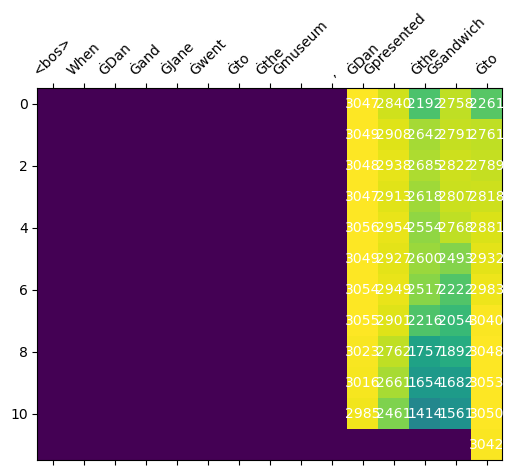

In [14]:
visualize_mask(model, mask.cpu(), clean_prompts[0])

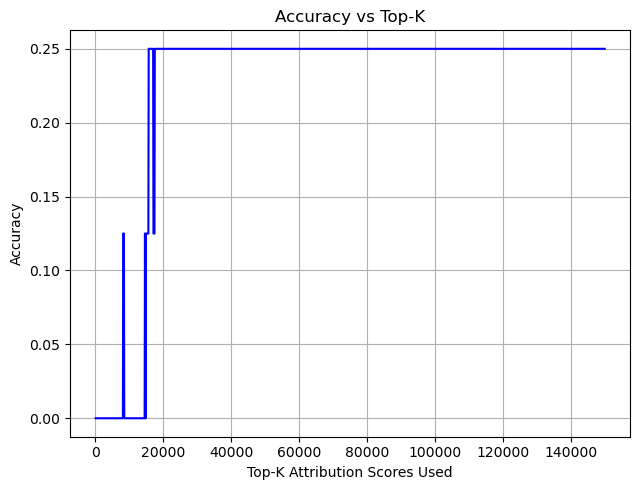

In [11]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.plot(ks, accuracies, label="Accuracy", color="blue")
plt.xlabel("Top-K Attribution Scores Used")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Top-K")
plt.grid(True)

# plt.subplot(1, 3, 2)
# plt.plot(ks, logit_diffs, label="Logit Diff", color="red")
# plt.xlabel("Top-K Attribution Scores Used")
# plt.ylabel("Mean Logit Diff")
# plt.title("Logit Difference vs Top-K")
# plt.grid(True)

# plt.subplot(1, 3, 3)
# plt.plot(ks, kl_divs, label="KL Divergence", color="green")
# plt.xlabel("Top-K Attribution Scores Used")
# plt.ylabel("Mean KL Divergence to 1-hot")
# plt.title("KL Divergence vs Top-K")
# plt.grid(True)

plt.tight_layout()
plt.show()